# Beveridge Curve Analysis

In [148]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Set the theme for seaborn
sns.set_theme(style="whitegrid", palette="Set2", context="talk", font_scale=0.85)

## Loading the data

Data is from FRED, the Federal Reserve Economic Data database. We have two datasets: one for the unemployment rate (UNRATE) and one for job openings (JTSJOR).

In [136]:
unemployment = pd.read_csv("raw_data/UNRATE.csv")
unemployment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 937 entries, 0 to 936
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  937 non-null    object 
 1   UNRATE            936 non-null    float64
dtypes: float64(1), object(1)
memory usage: 14.8+ KB


In [137]:
job_openings = pd.read_csv("raw_data/JTSJOR.csv")
job_openings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  301 non-null    object 
 1   JTSJOR            301 non-null    float64
dtypes: float64(1), object(1)
memory usage: 4.8+ KB


## Cleaning

In [138]:
unemployment.isna().sum()

observation_date    0
UNRATE              1
dtype: int64

Looks like we have one missing value in the umemployment dataset. Let's forward-fill it to maintain the continuity of the data.

In [139]:
unemployment.loc[unemployment.isna().any(axis=1)]
unemployment = unemployment.ffill()
unemployment.isna().sum()

observation_date    0
UNRATE              0
dtype: int64

In [140]:
job_openings.isna().sum()

observation_date    0
JTSJOR              0
dtype: int64

Nice—job openings data has no missing values.

We're going to want our date columns to be in datetime format for easier merging and plotting later on. Let's convert them and set them as the indices.

In [141]:
unemployment['observation_date'] = pd.to_datetime(unemployment['observation_date'])
unemployment = unemployment.set_index('observation_date')
unemployment.index.dtype

dtype('<M8[ns]')

In [142]:
job_openings['observation_date'] = pd.to_datetime(job_openings['observation_date'])
job_openings = job_openings.set_index('observation_date')
job_openings.index.dtype

dtype('<M8[ns]')

## Merging

We'll merge the unemployment and job openings data, only keeping rows where we have data for both.

In [143]:
merged_data = pd.merge(unemployment, job_openings, left_index=True, right_index=True)
merged_data.head()

,UNRATE,JTSJOR
observation_date,,
2000-12-01,3.9,3.7
2001-01-01,4.2,3.8
2001-02-01,4.2,3.7
2001-03-01,4.3,3.5
2001-04-01,4.4,3.4


In [144]:
merged_data.isna().sum()

UNRATE    0
JTSJOR    0
dtype: int64

Looks good—no missing values in the merged dataset. Now let's rename the columns for clarity.

In [145]:
merged_data = merged_data.rename(columns={'UNRATE': 'unemployment_rate', 'JTSJOR': 'job_openings'})

## Beveridge Curve Plotting

We're going to analyze three regimes: Pre-2008, 2008–2019, and 2020–present. Let's create a new column to categorize the data into these regimes, then plot.

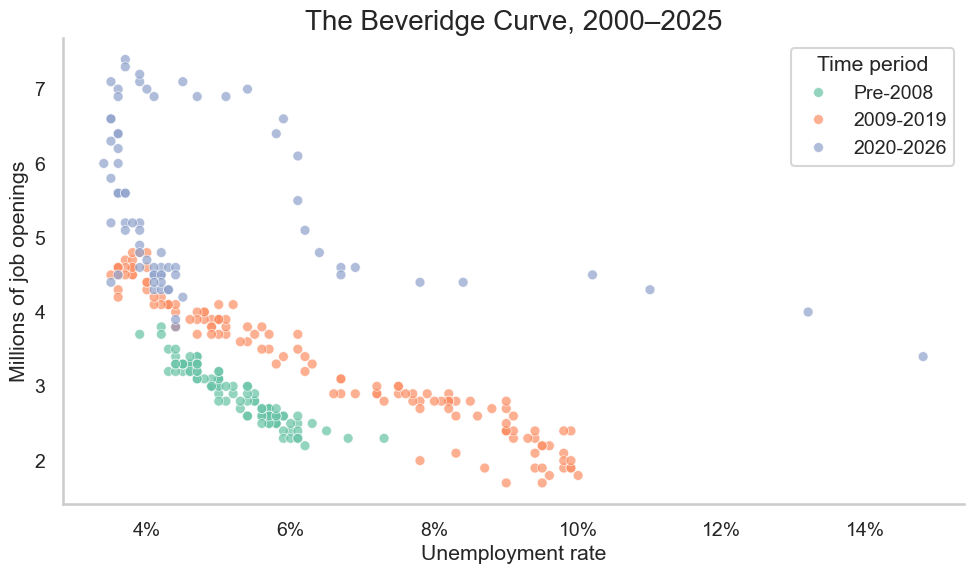

In [177]:
merged_data['time_period'] = pd.cut(
    merged_data.index.year, 
    bins=[0, 2008, 2019, 2026], 
    labels=['Pre-2008', '2009-2019', '2020-2026']
)

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
sns.scatterplot(data=merged_data, x='unemployment_rate', y='job_openings', hue='time_period', ax=ax, s=50, alpha=0.7)

ax.set_title('The Beveridge Curve, 2000–2025', fontsize=20)
ax.set_xlabel('Unemployment rate')
ax.set_ylabel('Millions of job openings')
ax.legend(title="Time period")

ax.grid(False)

ax.xaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))

plt.tight_layout()
sns.despine()

## Analysis
